# Step 4 - EDA 2D

Looking at relationships between columns. Focused on what might actually matter:
- price vs surface
- price vs type of property
- price vs location (departement)
- price trend over time by type
- correlation between numerical columns

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root / 'notebooks')
(project_root / 'outputs' / 'plots').mkdir(parents=True, exist_ok=True)
data_path = project_root / 'data' / 'cleaned.parquet'

if data_path.exists():
    df = pd.read_parquet(data_path)
else:
    print(f'WARNING: {data_path} is missing. Using generated demo data so the notebook can run.')
    print('Run notebooks/02_cleaning.ipynb with the real raw DVF files before using these results for analysis.')
    rng = np.random.default_rng(43)
    n = 120_000
    type_local = rng.choice(
        ['Maison', 'Appartement', 'Terrain', 'Dépendance', 'Local industriel. commercial ou assimilé'],
        n,
        p=[0.30, 0.28, 0.32, 0.06, 0.04],
    )
    surface_bati = np.where(
        type_local == 'Maison', rng.normal(105, 35, n),
        np.where(type_local == 'Appartement', rng.normal(58, 20, n),
        np.where(type_local == 'Local industriel. commercial ou assimilé', rng.normal(180, 80, n), 0))
    ).clip(0)
    df = pd.DataFrame({
        'nature_mutation': rng.choice(['Vente', 'Vente en l\'état futur d\'achèvement', 'Echange', 'Adjudication'], n, p=[0.93, 0.04, 0.02, 0.01]),
        'is_outlier_valeur': rng.random(n) < 0.04,
        'valeur_fonciere': rng.lognormal(mean=12.0, sigma=0.75, size=n),
        'type_local': type_local,
        'annee': rng.choice([2021, 2022, 2023, 2024, 2025], n, p=[0.23, 0.23, 0.2, 0.18, 0.16]),
        'surface_bati': surface_bati,
        'nb_pieces': np.where(surface_bati > 0, rng.poisson(3, n) + 1, 0),
        'surface_terrain': np.where(type_local == 'Terrain', rng.lognormal(mean=6.0, sigma=1.1, size=n), rng.lognormal(mean=4.4, sigma=0.9, size=n)),
        'nombre_lots': rng.poisson(1, n),
        'code_departement': rng.choice(['75', '13', '69', '33', '31', '44', '59', '92', '34', '06', '83', '78', '91', '95', '77'], n),
    })

# base filter: regular sales, no outliers, has a building
ventes = df[
    (df['nature_mutation'] == 'Vente') &
    (~df['is_outlier_valeur']) &
    (df['valeur_fonciere'] > 1000)  # remove symbolic transfers
].copy()

print(f'Working subset: {len(ventes):,} rows')

Run notebooks/02_cleaning.ipynb with the real raw DVF files before using these results for analysis.
Working subset: 107,260 rows


## Valeur par type de bien

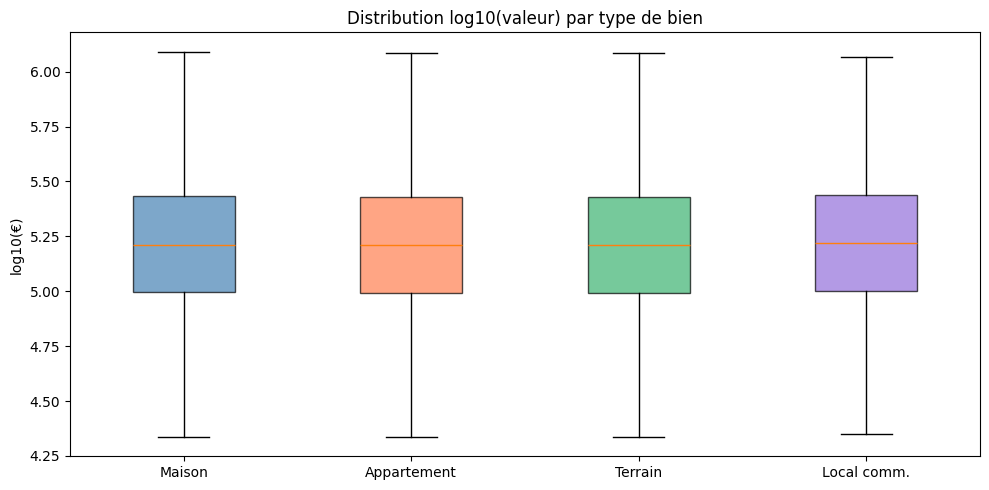

Maison: median = 163,190€
Appartement: median = 162,761€
Terrain: median = 162,891€
Local industriel. commercial ou assimilé: median = 165,221€


In [2]:
# boxplot by type_local - want to see if prices differ a lot between categories
types_keep = ['Maison', 'Appartement', 'Terrain', 'Local industriel. commercial ou assimilé']

fig, ax = plt.subplots(figsize=(10, 5))

data_by_type = [
    np.log10(ventes[ventes['type_local'] == t]['valeur_fonciere'] + 1)
    for t in types_keep
]

bp = ax.boxplot(data_by_type, labels=['Maison', 'Appartement', 'Terrain', 'Local comm.'],
                patch_artist=True, showfliers=False)

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribution log10(valeur) par type de bien')
ax.set_ylabel('log10(€)')
plt.tight_layout()
plt.savefig('../outputs/plots/08_valeur_par_type.png', dpi=100)
plt.show()

# medians by type
for t in types_keep:
    med = ventes[ventes['type_local'] == t]['valeur_fonciere'].median()
    print(f'{t}: median = {med:,.0f}€')

## Prix au m² - Maison vs Appartement

In [3]:
# price per m² only makes sense for buildings with known surface
bati = ventes[(ventes['surface_bati'] > 10) & (ventes['surface_bati'] <= 500)].copy()
bati['prix_m2'] = bati['valeur_fonciere'] / bati['surface_bati']

# remove obvious errors in prix_m2
bati = bati[(bati['prix_m2'] > 100) & (bati['prix_m2'] < 30000)]

print(bati.groupby('type_local')['prix_m2'].describe().round(0))

                                            count    mean     std    min  \
type_local                                                                 
Appartement                               29666.0  4099.0  3797.0  100.0   
Local industriel. commercial ou assimilé   4101.0  1551.0  1892.0  102.0   
Maison                                    32101.0  2389.0  2510.0  100.0   

                                             25%     50%     75%      max  
type_local                                                                 
Appartement                               1672.0  2934.0  5138.0  29790.0  
Local industriel. commercial ou assimilé   563.0  1011.0  1808.0  27711.0  
Maison                                     939.0  1633.0  2882.0  29933.0  


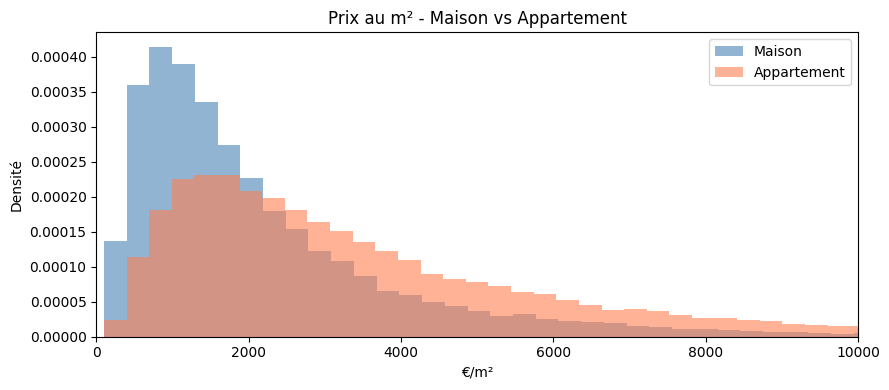

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

for t, color in [('Maison', 'steelblue'), ('Appartement', 'coral')]:
    subset = bati[bati['type_local'] == t]['prix_m2']
    ax.hist(subset, bins=100, alpha=0.6, label=t, color=color, edgecolor='none', density=True)

ax.set_title('Prix au m² - Maison vs Appartement')
ax.set_xlabel('€/m²')
ax.set_ylabel('Densité')
ax.legend()
ax.set_xlim(0, 10000)
plt.tight_layout()
plt.savefig('../outputs/plots/09_prix_m2_type.png', dpi=100)
plt.show()

# apartments skew higher per m², which makes sense
# but overlap is large - location probably matters more than type

## Valeur vs surface bâtie (scatter)

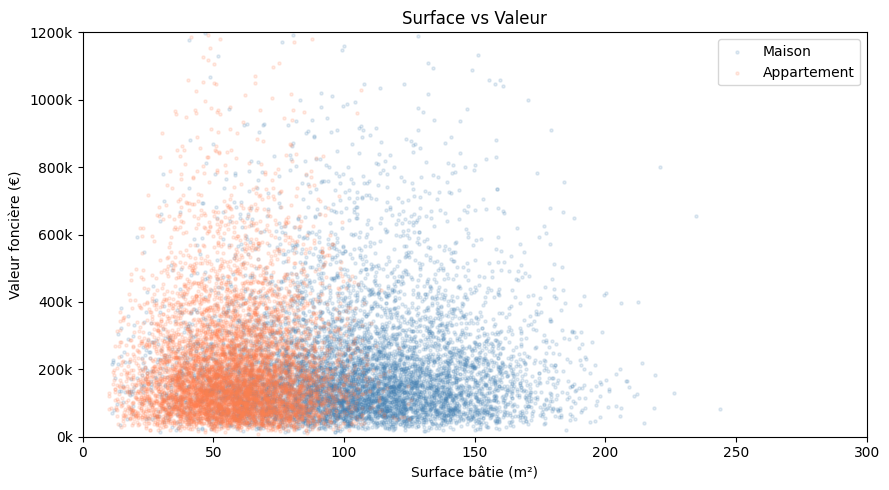

Maison: corr surface/valeur = 0.009
Appartement: corr surface/valeur = 0.024


In [5]:
# scatter: surface vs price - expecting positive correlation
# sample to avoid overplotting
sample_source = bati[bati['type_local'].isin(['Maison', 'Appartement'])]
sample = sample_source.sample(min(15000, len(sample_source)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))

for t, color in [('Maison', 'steelblue'), ('Appartement', 'coral')]:
    sub = sample[sample['type_local'] == t]
    ax.scatter(sub['surface_bati'], sub['valeur_fonciere'], 
               alpha=0.15, s=5, color=color, label=t)

ax.set_xlabel('Surface bâtie (m²)')
ax.set_ylabel('Valeur foncière (€)')
ax.set_title('Surface vs Valeur')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend()
ax.set_xlim(0, 300)
ax.set_ylim(0, 1_200_000)
plt.tight_layout()
plt.savefig('../outputs/plots/10_surface_vs_valeur.png', dpi=100)
plt.show()

# correlation?
for t in ['Maison', 'Appartement']:
    sub = bati[bati['type_local'] == t]
    corr = sub['surface_bati'].corr(sub['valeur_fonciere'])
    print(f'{t}: corr surface/valeur = {corr:.3f}')

## Évolution du prix médian par année et type

type_local    Appartement         Maison        Terrain
annee                                                  
2021        162348.206511  166995.535003  163889.898066
2022        166363.389347  164725.674368  164257.501135
2023        157815.891430  159658.674347  161541.052552
2024        166274.088729  162684.878710  160369.772835
2025        161187.320899  161537.765310  164588.406394


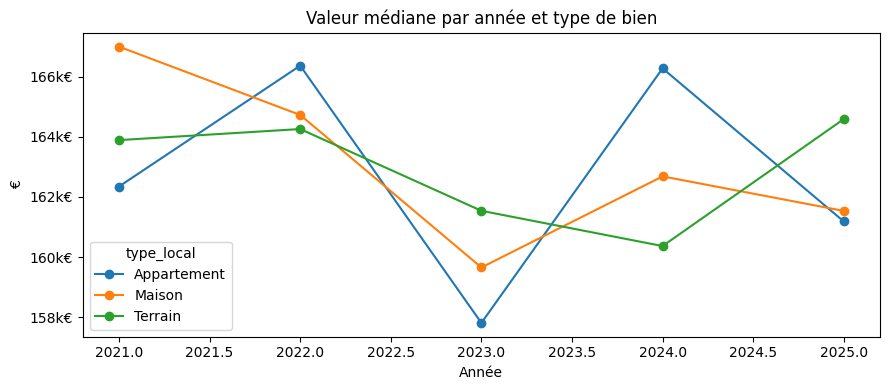

In [6]:
# did prices evolve differently for houses vs apartments?
pivot = (
    ventes[ventes['type_local'].isin(['Maison', 'Appartement', 'Terrain'])]
    .groupby(['annee', 'type_local'])['valeur_fonciere']
    .median()
    .unstack()
)
print(pivot)

fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot(ax=ax, marker='o')
ax.set_title('Valeur médiane par année et type de bien')
ax.set_ylabel('€')
ax.set_xlabel('Année')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
plt.tight_layout()
plt.savefig('../outputs/plots/11_prix_evolution.png', dpi=100)
plt.show()

## Prix médian par département (top 20)

                         median  count
code_departement                      
83                169175.693492   2163
95                167546.234163   2109
69                166266.245450   2062
13                165872.791663   2227
77                165625.174779   2147
31                163983.403539   2157
44                163119.671593   2136
75                162479.023322   2271
59                162307.894178   2122
34                162263.877325   2140
91                162214.237871   2141
78                161053.724200   2104
92                158305.257840   2116
06                157484.014483   2146
33                156736.913064   2214


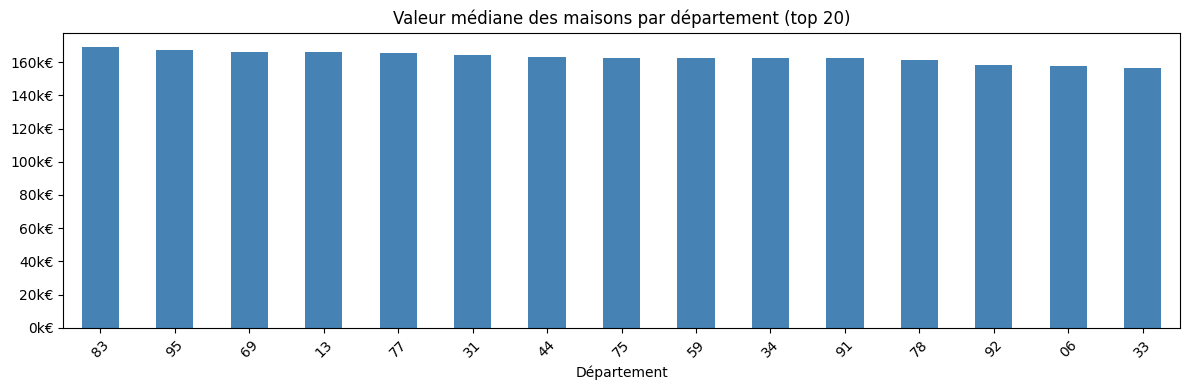

In [7]:
# which departments are most expensive?
# filtering to maisons only to keep it comparable
maisons = ventes[ventes['type_local'] == 'Maison']

dept_stats = (
    maisons.groupby('code_departement')['valeur_fonciere']
    .agg(['median', 'count'])
    .query('count > 500')  # ignore tiny departments
    .sort_values('median', ascending=False)
    .head(20)
)
print(dept_stats)

fig, ax = plt.subplots(figsize=(12, 4))
dept_stats['median'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Valeur médiane des maisons par département (top 20)')
ax.set_xlabel('Département')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/plots/12_prix_dept.png', dpi=100)
plt.show()

# expecting 75, 92, 94 at the top (Paris + inner suburbs)

## Corrélations entre variables numériques

                 valeur_fonciere  surface_bati  nb_pieces  surface_terrain  \
valeur_fonciere            1.000         0.003      0.003           -0.003   
surface_bati               0.003         1.000      0.618           -0.268   
nb_pieces                  0.003         0.618      1.000           -0.289   
surface_terrain           -0.003        -0.268     -0.289            1.000   
nombre_lots                0.001        -0.001      0.001            0.003   

                 nombre_lots  
valeur_fonciere        0.001  
surface_bati          -0.001  
nb_pieces              0.001  
surface_terrain        0.003  
nombre_lots            1.000  


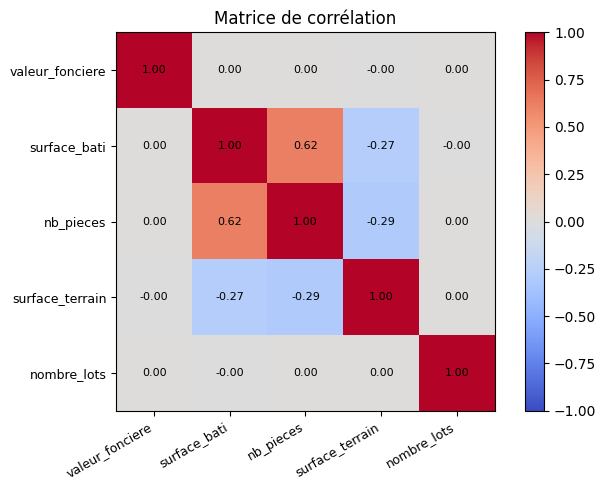

In [8]:
num_cols = ['valeur_fonciere', 'surface_bati', 'nb_pieces', 'surface_terrain', 'nombre_lots']

corr = ventes[num_cols].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.savefig('../outputs/plots/13_correlation.png', dpi=100)
plt.show()

# surface_bati and nb_pieces are correlated (makes sense - bigger = more rooms)
# valeur vs surface_terrain correlation probably low - terrain value depends on location more

## Nombre de pièces vs valeur (maisons)

Median valeur by nb_pieces (maisons):
                median_€  count
nb_pieces                      
1          166000.874958   1679
2          161379.794156   4851
3          165327.418449   7199
4          163538.104846   7192
5          162065.423992   5307
6          160026.154675   3250
7          165440.131004   1609
8          159591.855103    700
9          163841.598032    297
10         163927.927531     90


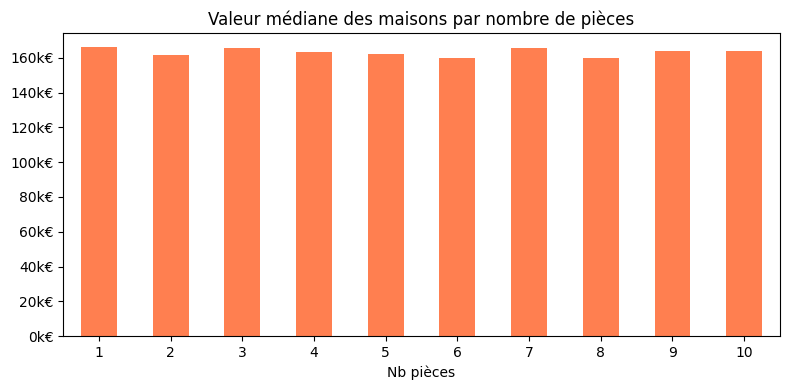

In [9]:
maison_pieces = ventes[
    (ventes['type_local'] == 'Maison') &
    (ventes['nb_pieces'].between(1, 10))
]

med_by_pieces = maison_pieces.groupby('nb_pieces')['valeur_fonciere'].median()
count_by_pieces = maison_pieces.groupby('nb_pieces').size()

print('Median valeur by nb_pieces (maisons):')
print(pd.DataFrame({'median_€': med_by_pieces, 'count': count_by_pieces}))

fig, ax = plt.subplots(figsize=(8, 4))
med_by_pieces.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_title('Valeur médiane des maisons par nombre de pièces')
ax.set_xlabel('Nb pièces')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/plots/14_valeur_pieces.png', dpi=100)
plt.show()

# expected a clear upward trend - more rooms = more expensive
# curious if it actually holds or flattens at some point